# 02: Exploratory Data Analysis

**Dataset:** Google Analytics Sample Ecommerce Dataset (BigQuery public data)  
**Goal:** Understand user behavior by traffic source, device, geography, campaign, and purchase patterns over time.  
**Reference:** [GA BigQuery Export Schema](https://support.google.com/analytics/answer/3437719?hl=en)

## 1. Setup

In [1]:
import os
from google.cloud import bigquery
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.width', 1000)

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../credentials/bq-key.json"
client = bigquery.Client()
print("BigQuery client ready.")

BigQuery client ready.


## 2. Traffic Sources
*Full year | Real bounce rate (single-pageview sessions) per traffic source*

In [2]:
query_bounce_channel = """
    SELECT 
    trafficSource.source,
    count(*) as sessions,
    ROUND(AVG(CASE WHEN totals.bounces IS NULL THEN 0 ELSE totals.bounces END) * 100, 1) AS bounce_rate_pct
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
    GROUP BY trafficSource.source
    ORDER BY sessions desc
"""

df_bounce_channel = client.query(query_bounce_channel).to_dataframe()
df_bounce_channel = df_bounce_channel.sort_values('sessions', ascending = False)
df_bounce_channel.head(15)

,source,sessions,bounce_rate_pct
0,(direct),371469,41.8
1,google,241280,48.3
2,youtube.com,212602,66.0
3,Partners,16411,53.1
4,analytics.google.com,16172,52.3
5,dfa,5686,36.1
6,google.com,4669,42.6
7,m.facebook.com,3365,61.0
8,baidu,3356,67.8
9,sites.google.com,2983,33.5


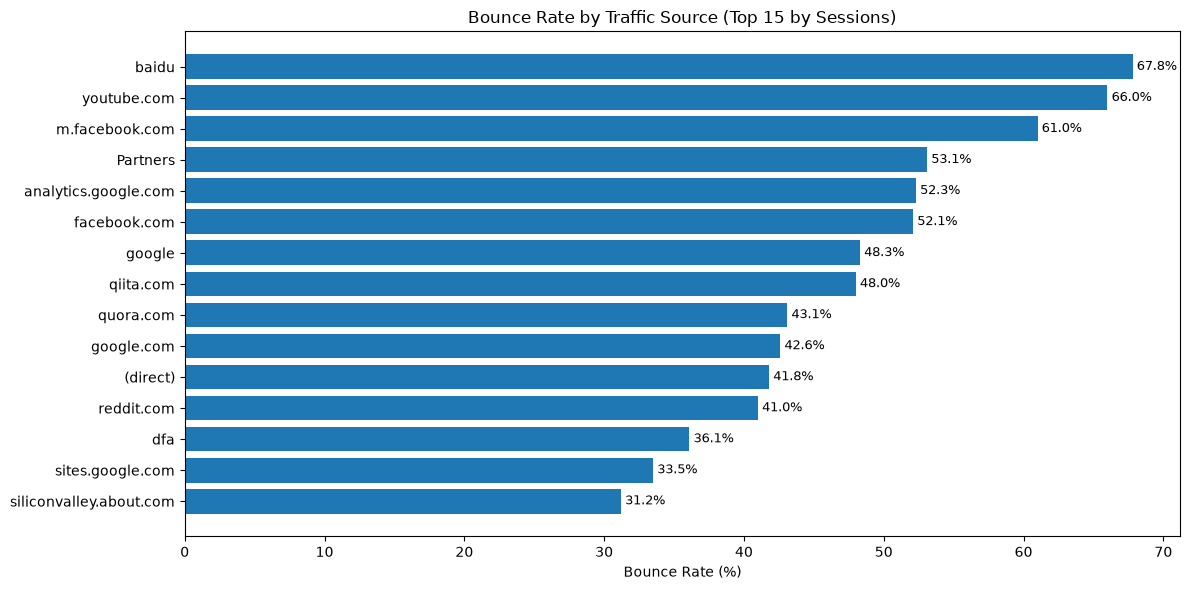

In [3]:
top15 = df_bounce_channel.head(15).sort_values('bounce_rate_pct', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top15['source'], top15['bounce_rate_pct'], color = 'tab:blue')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_title('Bounce Rate by Traffic Source (Top 15 by Sessions)')
ax.set_xlabel('Bounce Rate (%)')
plt.tight_layout()
plt.savefig('../images/real_bounce_rate.png', dpi=150)
plt.show()

**Insights:**
1. Top 3 sources dominate completely - Direct (371K), Google (241K), YouTube (213K) account for ~91% of all traffic. Everything else is a long tail.
2. YouTube is high volume, low quality - 3rd largest source but 66% bounce rate. High reach, low intent.
3. Direct traffic is the best overall - 371K sessions at 41.8% bounce, the best combination of volume and engagement.
4. Google organic is mid-range - 48.3% bounce suggests mixed intent.
5. `analytics.google.com` is noise, not customers - confirmed by the queries below: 16,172 sessions, 0 transactions, 0% conversion, spread across 122 countries. These are likely Google employees or anyone with GA dashboard access clicking through to the store - not real buyers. **Excluded from the channel grouping analysis in Sections 7c and 7d** so it does not dilute Referral's true conversion rate.
6. `sites.google.com` is small but genuine - 2,983 sessions, 43 transactions, 1.44% conversion rate (above the site average of 1.34%), &#36;121 AOV, 33.5% bounce rate across 35 countries. People arriving from a Google Sites page have a specific reason for clicking - this is real curated-link Referral traffic, unlike `analytics.google.com`.

In [4]:
query_analytics_source = """
SELECT
    trafficSource.medium AS medium,
    channelGrouping,
    geoNetwork.country AS country,
    device.deviceCategory AS device,
    COUNT(*) AS sessions,
    SUM(IFNULL(totals.transactions, 0)) AS transactions,
    ROUND(SUM(IFNULL(totals.transactions, 0)) / COUNT(*) * 100, 2) AS conversion_rate_pct,
    ROUND(AVG(CASE WHEN totals.bounces IS NULL THEN 0 ELSE totals.bounces END) * 100, 1) AS bounce_rate_pct
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE trafficSource.source = 'analytics.google.com'
GROUP BY medium, channelGrouping, country, device
ORDER BY sessions DESC
"""
df_analytics = client.query(query_analytics_source).to_dataframe()
print(f"Total sessions from analytics.google.com: {df_analytics['sessions'].sum():,}")
df_analytics

Total sessions from analytics.google.com: 16,172


,medium,channelGrouping,country,device,sessions,transactions,conversion_rate_pct,bounce_rate_pct
0,referral,Referral,United States,desktop,3046,0,0.0,53.4
1,referral,Referral,Taiwan,desktop,1125,0,0.0,45.4
2,referral,Referral,India,desktop,959,0,0.0,53.9
3,referral,Referral,Spain,desktop,940,0,0.0,53.2
4,referral,Referral,Japan,desktop,931,0,0.0,45.5
...,...,...,...,...,...,...,...,...
171,referral,Referral,India,tablet,1,0,0.0,100.0
172,referral,Referral,Somalia,desktop,1,0,0.0,0.0
173,referral,Referral,Denmark,tablet,1,0,0.0,0.0
174,referral,Referral,Thailand,mobile,1,0,0.0,100.0


In [5]:
query_analytics_summary = """
SELECT
    COUNT(*) AS sessions,
    SUM(IFNULL(totals.transactions, 0)) AS total_transactions,
    ROUND(SUM(IFNULL(totals.transactions, 0)) / COUNT(*) * 100, 4) AS conversion_rate_pct,
    COUNT(DISTINCT geoNetwork.country) AS countries,
    ROUND(AVG(CASE WHEN totals.bounces IS NULL THEN 0 ELSE totals.bounces END) * 100, 1) AS avg_bounce_rate_pct
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE trafficSource.source = 'analytics.google.com'
"""
client.query(query_analytics_summary).to_dataframe()

,sessions,total_transactions,conversion_rate_pct,countries,avg_bounce_rate_pct
0,16172,0,0.0,122,52.3


In [6]:
query_sites_summary = """
SELECT
    COUNT(*) AS sessions,
    SUM(IFNULL(totals.transactions, 0)) AS transactions,
    ROUND(SUM(IFNULL(totals.transactions, 0)) / COUNT(*) * 100, 2) AS conversion_rate_pct,
    ROUND(SUM(IFNULL(totals.totalTransactionRevenue, 0)) / 1000000, 2) AS revenue,
    ROUND(SUM(totals.totalTransactionRevenue) / 1000000 / SUM(totals.transactions), 2) AS avg_order_value,
    ROUND(AVG(CASE WHEN totals.bounces IS NULL THEN 0 ELSE totals.bounces END) * 100, 1) AS bounce_rate_pct,
    COUNT(DISTINCT geoNetwork.country) AS countries
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE trafficSource.source = 'sites.google.com'
"""
print("sites.google.com summary:")
client.query(query_sites_summary).to_dataframe()

sites.google.com summary:


,sessions,transactions,conversion_rate_pct,revenue,avg_order_value,bounce_rate_pct,countries
0,2983,43,1.44,5212.2,121.21,33.5,35


## 3. Device & Browser
*Full year | Total transactions per browser*

In [7]:
query_browser = """
SELECT
    device.browser AS browser,
    COUNT(*) AS sessions,
    SUM(totals.transactions) AS transactions,
    ROUND(SUM(totals.transactions) / COUNT(*) * 100, 2) AS conversion_rate_pct,
    ROUND(SUM(totals.totalTransactionRevenue) / 1000000, 0) AS revenue
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
GROUP BY browser
ORDER BY transactions DESC
"""

df_browser = client.query(query_browser).to_dataframe()
df_browser['transactions'] = df_browser['transactions'].fillna(0).astype(int)
df_browser['conversion_rate_pct'] = df_browser['conversion_rate_pct'].fillna(0).astype(float)
df_browser.head(15)

,browser,sessions,transactions,conversion_rate_pct,revenue
0,Chrome,620364,10924,1.76,1562955.0
1,Safari,182245,787,0.43,57410.0
2,Firefox,37069,207,0.56,142659.0
3,Internet Explorer,19375,113,0.58,8902.0
4,Edge,10205,59,0.58,7551.0
5,Safari (in-app),6850,12,0.18,207.0
6,Android Webview,7865,6,0.08,151.0
7,Opera,5643,6,0.11,278.0
8,Amazon Silk,561,1,0.18,37.0
9,NokiaE52-1,2,0,0.00,NaN


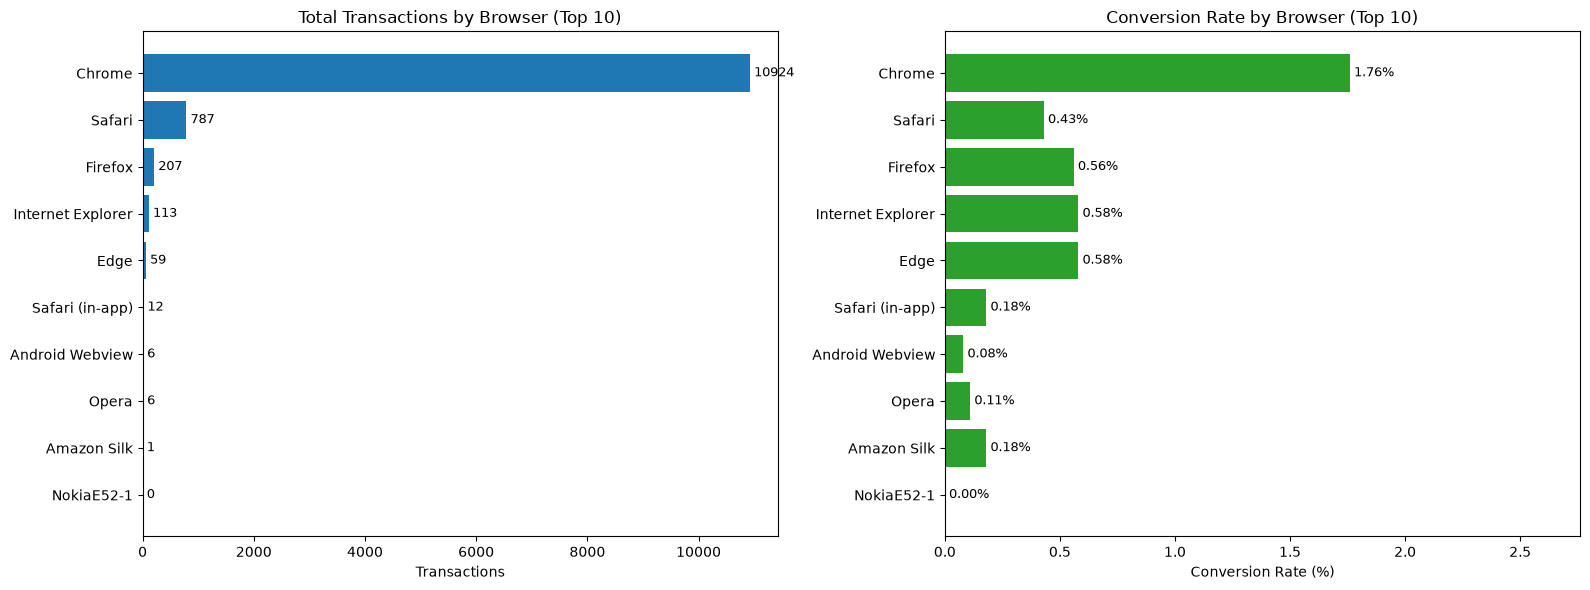

In [8]:
top10 = df_browser.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# left - total transactions
bars1 = axes[0].barh(top10['browser'][::-1], top10['transactions'][::-1], color='tab:blue')
axes[0].bar_label(bars1, fmt='%.0f', padding=3, fontsize=9)
axes[0].set_title('Total Transactions by Browser (Top 10)')
axes[0].set_xlabel('Transactions')
axes[0].set_xlim(0, top10['transactions'].max() + 500)

# right - conversion rate
bars2 = axes[1].barh(top10['browser'][::-1], top10['conversion_rate_pct'][::-1], color='tab:green')
axes[1].bar_label(bars2, fmt='%.2f%%', padding=3, fontsize=9)
axes[1].set_title('Conversion Rate by Browser (Top 10)')
axes[1].set_xlabel('Conversion Rate (%)')
axes[1].set_xlim(0, top10['conversion_rate_pct'].max() + 1)

plt.tight_layout()
plt.savefig('../images/browser_transactions.png', dpi=150)
plt.show()

**Insights:**
1. Chrome leads on both volume and conversion rate - 10,924 transactions and 1.76% conversion rate, far ahead of every other browser on both dimensions.
2. Safari has high volume but low conversion - 787 transactions but only 0.43% conversion rate, the lowest among desktop browsers.
3. Firefox and IE have lower transaction counts but higher conversion rates than Safari, suggesting their users tend to have more purchase intent.
4. Mobile browsers barely convert - Safari (in-app) at 0.18% and Android Webview at 0.08% confirm that in-app and mobile webview users are not completing purchases.
5. Chrome's 1.76% is well above the overall average (1.34%) - since Chrome dominates total traffic, it also pulls the overall average up. All other browsers sit below the site average.

## 4. Geography
*Full year | Sessions and revenue by country*

In [9]:
query_country = """
SELECT
    geoNetwork.country AS country,
    COUNT(*) AS sessions,
    SUM(totals.transactions) AS transactions,
    ROUND(SUM(totals.transactions) / COUNT(*) * 100, 2) AS conversion_rate_pct,
    ROUND(SUM(totals.totalTransactionRevenue) / 1000000, 0) AS revenue
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
GROUP BY country
ORDER BY sessions DESC
"""

df_country = client.query(query_country).to_dataframe()
df_country['session_pct'] = round(100 * df_country['sessions']/df_country['sessions'].sum(),2)
df_country['transactions'] = df_country['transactions'].fillna(0).astype(int)
df_country['transaction_pct'] = round(100 * df_country['transactions']/df_country['transactions'].sum(),2)
df_country['revenue_pct'] = round(100 * df_country['revenue']/df_country['revenue'].sum(),2)
df_country['revenue'] = df_country['revenue'].fillna(0)
df_country['conversion_rate_pct'] = df_country['conversion_rate_pct'].fillna(0)
df_country['revenue_pct'] = df_country['revenue_pct'].fillna(0)
df_country['avg_order_value'] = (df_country['revenue'] / df_country['transactions'].where(df_country['transactions'] > 0)).round(2)
df_country['avg_order_value'] = df_country['avg_order_value'].fillna(0)
df_country = df_country[['country','sessions','session_pct','transactions','transaction_pct','conversion_rate_pct','revenue','revenue_pct','avg_order_value']]
df_country.head(15)

,country,sessions,session_pct,transactions,transaction_pct,conversion_rate_pct,revenue,revenue_pct,avg_order_value
0,United States,364744,40.36,11440,94.43,3.14,1664261.0,93.49,145.48
1,India,51140,5.66,10,0.08,0.02,751.0,0.04,75.10
2,United Kingdom,37393,4.14,19,0.16,0.05,1962.0,0.11,103.26
3,Canada,25869,2.86,199,1.64,0.77,34922.0,1.96,175.49
4,Vietnam,24598,2.72,0,0.00,0.00,0.0,0.00,0.00
5,Turkey,20522,2.27,2,0.02,0.01,117.0,0.01,58.50
6,Thailand,20123,2.23,5,0.04,0.02,492.0,0.03,98.40
7,Germany,19980,2.21,8,0.07,0.04,586.0,0.03,73.25
8,Brazil,19783,2.19,10,0.08,0.05,689.0,0.04,68.90
9,Japan,19731,2.18,18,0.15,0.09,7629.0,0.43,423.83


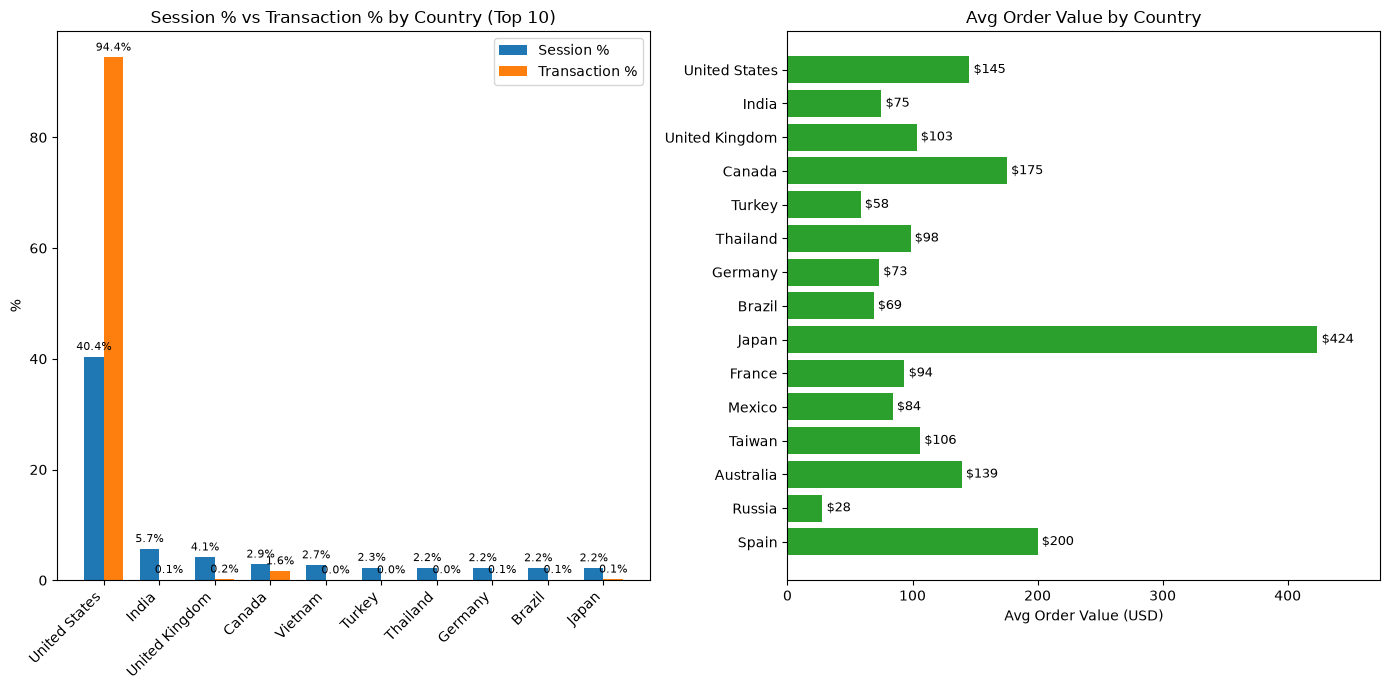

In [10]:
top10 = df_country.head(10)
top10_with_transactions = df_country[df_country['transactions'] > 0].head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# left - session % vs transaction % grouped bars
x = np.arange(len(top10))
width = 0.35

bars1 = axes[0].bar(x - width/2, top10['session_pct'], width, label='Session %', color='tab:blue')
bars2 = axes[0].bar(x + width/2, top10['transaction_pct'], width, label='Transaction %', color='tab:orange')
axes[0].bar_label(bars1, fmt='%.1f%%', padding=3, fontsize=8)
axes[0].bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=8)
axes[0].set_title('Session % vs Transaction % by Country (Top 10)')
axes[0].set_ylabel('%')
axes[0].set_xticks(x)
axes[0].set_xticklabels(top10['country'], rotation=45, ha='right')
axes[0].legend()

# right - avg order value (countries with transactions only)
bars3 = axes[1].barh(
    top10_with_transactions['country'][::-1],
    top10_with_transactions['avg_order_value'][::-1],
    color='tab:green'
)
axes[1].bar_label(bars3, fmt='$%.0f', padding=3, fontsize=9)
axes[1].set_title('Avg Order Value by Country')
axes[1].set_xlabel('Avg Order Value (USD)')
axes[1].set_xlim(0, top10_with_transactions['avg_order_value'].max() + 50)

plt.tight_layout()
plt.savefig('../images/country_performance.png', dpi=150)
plt.show()

**Insights:**
1. The US massively overperforms its traffic share - 40.4% of sessions but 94.4% of transactions and 93.5% of revenue. Conversion rate (3.14%) dwarfs every other country.
2. Canada is the only other market with real traction - 0.77% conversion rate and AOV of &#36;175.
3. Japan's &#36;424 AOV is misleading - see deep dive below.
4. Large markets with almost no conversion - India, Vietnam, Turkey, Thailand, Germany collectively drive significant traffic but all under 0.1% conversion. Vietnam has 24K sessions and zero transactions.
5. Outside the US and Canada, every country converts below 0.15% - likely a targeting mismatch or localization barrier.

#### Japan Deep Dive - Is the High AOV Driven by Outliers?
*Japan has only 18 transactions total. Check individual transaction values to assess reliability of the &#36;424 AOV.*

In [11]:
query_japan_transactions = """
SELECT
    ROUND(totals.totalTransactionRevenue / 1000000, 2) AS revenue
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE geoNetwork.country = 'Japan'
AND totals.totalTransactionRevenue IS NOT NULL
ORDER BY revenue DESC
"""
df_japan = client.query(query_japan_transactions).to_dataframe()
print(f"Transactions: {len(df_japan)}")
print(f"Total revenue: ${df_japan['revenue'].sum():,.2f}")
print(f"AOV: ${df_japan['revenue'].mean():,.2f}")
print(f"Median: ${df_japan['revenue'].median():,.2f}")
print(f"Max: ${df_japan['revenue'].max():,.2f}")
print(f"Min: ${df_japan['revenue'].min():,.2f}")
print()
df_japan

Transactions: 17
Total revenue: $7,629.13
AOV: $448.77
Median: $49.94
Max: $3,394.80
Min: $25.99



,revenue
0,3394.80
1,2336.65
2,1054.00
3,180.97
4,104.60
5,102.95
6,88.85
7,56.97
8,49.94
9,42.98


**Insights:**
1. Japan's &#36;424 AOV is misleading - the top 3 transactions (&#36;3,395 / &#36;2,337 / &#36;1,054) account for 89% of total Japan revenue. Remove them and the remaining 14 orders average ~&#36;60.
2. Median spend is &#36;50 - well below the US average of &#36;145. Japan is not a premium market; it just has 3 extreme outliers inflating the mean.
3. With only 17 transactions over the full year, Japan has too little data to draw reliable conclusions about buyer behavior.

## 5. Pageview Depth
*Full year | Avg product pageviews for purchasers vs non-purchasers*

In [12]:
query_pageviews = """
SELECT
    purchased,
    COUNT(*) AS users,
    ROUND(AVG(total_pageviews), 2) AS avg_pageviews,
    MIN(total_pageviews) AS min_pageviews,
    APPROX_QUANTILES(total_pageviews, 100)[OFFSET(25)] AS p25,
    APPROX_QUANTILES(total_pageviews, 100)[OFFSET(50)] AS p50,
    APPROX_QUANTILES(total_pageviews, 100)[OFFSET(75)] AS p75,
    APPROX_QUANTILES(total_pageviews, 100)[OFFSET(90)] AS p90,
    APPROX_QUANTILES(total_pageviews, 100)[OFFSET(95)] AS p95,
    APPROX_QUANTILES(total_pageviews, 100)[OFFSET(99)] AS p99,
    MAX(total_pageviews) AS max_pageviews
FROM (
    SELECT
        fullVisitorId,
        SUM(totals.pageviews) AS total_pageviews,
        IF(SUM(IFNULL(totals.transactions, 0)) > 0, 'Purchased', 'Not Purchased') AS purchased
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
    GROUP BY fullVisitorId
)
GROUP BY purchased
ORDER BY purchased DESC
"""

df_pageviews = client.query(query_pageviews).to_dataframe()
df_pageviews


,purchased,users,avg_pageviews,min_pageviews,p25,p50,p75,p90,p95,p99,max_pageviews
0,Purchased,10022,52.99,5,24,37,60,99,138,283,4160
1,Not Purchased,704145,4.19,1,1,2,4,9,16,37,2707


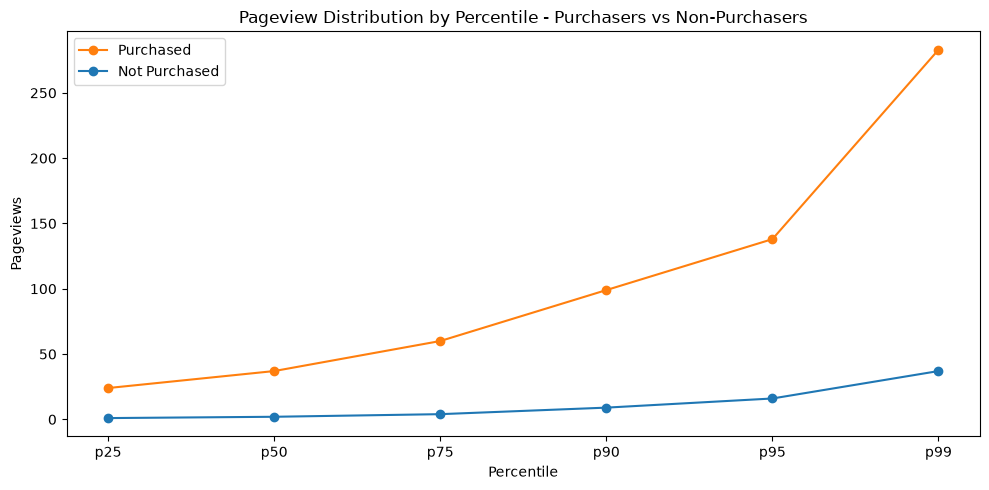

In [13]:
percentiles = ['p25', 'p50', 'p75', 'p90', 'p95', 'p99']
color_map = {'Purchased': 'tab:orange', 'Not Purchased': 'tab:blue'}

fig, ax = plt.subplots(figsize=(10, 5))
for _, row in df_pageviews.iterrows():
    ax.plot(percentiles, [row[p] for p in percentiles], marker='o',
            label=row['purchased'], color=color_map[row['purchased']])

ax.set_title('Pageview Distribution by Percentile - Purchasers vs Non-Purchasers')
ax.set_xlabel('Percentile')
ax.set_ylabel('Pageviews')
ax.legend()
plt.tight_layout()
plt.savefig('../images/pageviews_percentile.png', dpi=150)
plt.show()

In [14]:
query_pageviews_dist = """
SELECT
    purchased,
    FLOOR(total_pageviews / 2) * 2 AS pageview_bucket,
    COUNT(*) AS users
FROM (
    SELECT
        fullVisitorId,
        SUM(totals.pageviews) AS total_pageviews,
        IF(SUM(IFNULL(totals.transactions, 0)) > 0, 'Purchased', 'Not Purchased') AS purchased
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
    GROUP BY fullVisitorId
)
WHERE total_pageviews <= 150
GROUP BY purchased, pageview_bucket
ORDER BY purchased, pageview_bucket
"""

df_pageviews_dist = client.query(query_pageviews_dist).to_dataframe()
df_pageviews_dist.head(10)

,purchased,pageview_bucket,users
0,Not Purchased,0.0,338118
1,Not Purchased,2.0,178664
2,Not Purchased,4.0,60657
3,Not Purchased,6.0,34366
4,Not Purchased,8.0,22470
5,Not Purchased,10.0,15303
6,Not Purchased,12.0,10967
7,Not Purchased,14.0,8122
8,Not Purchased,16.0,6240
9,Not Purchased,18.0,4780


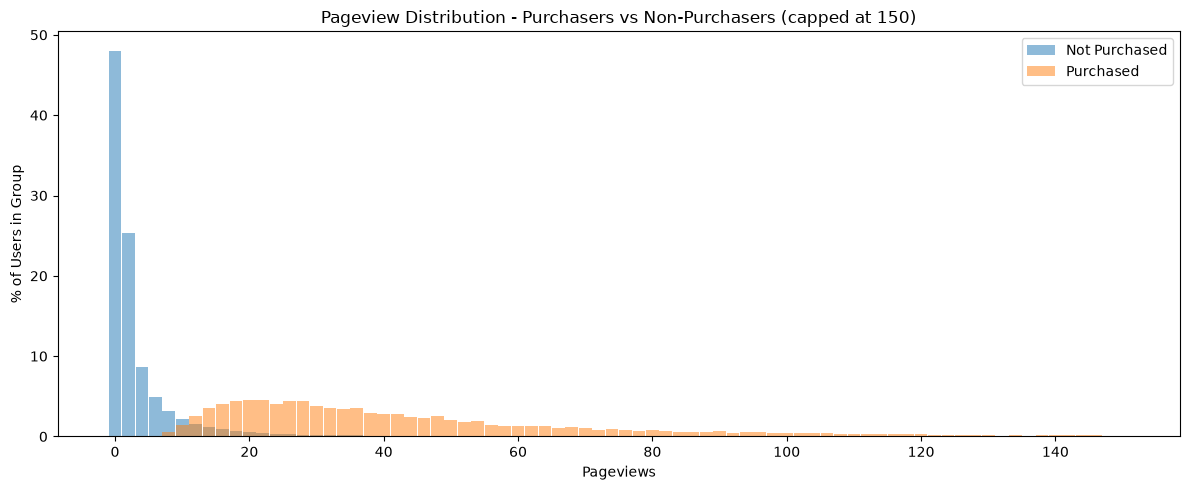

In [15]:
# normalize each group to % of their own total
total_not = df_pageviews_dist[df_pageviews_dist['purchased'] == 'Not Purchased']['users'].sum()
total_pur = df_pageviews_dist[df_pageviews_dist['purchased'] == 'Purchased']['users'].sum()

not_purchased = df_pageviews_dist[df_pageviews_dist['purchased'] == 'Not Purchased'].copy()
purchased = df_pageviews_dist[df_pageviews_dist['purchased'] == 'Purchased'].copy()

not_purchased['pct'] = not_purchased['users'] / total_not * 100
purchased['pct'] = purchased['users'] / total_pur * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(not_purchased['pageview_bucket'], not_purchased['pct'], width=1.9, color='tab:blue', alpha=0.5, label='Not Purchased')      # alpha controls transparency from 0 to 1
ax.bar(purchased['pageview_bucket'], purchased['pct'], width=1.9, color='tab:orange', alpha=0.5, label='Purchased')
ax.set_title('Pageview Distribution - Purchasers vs Non-Purchasers (capped at 150)')
ax.set_xlabel('Pageviews')
ax.set_ylabel('% of Users in Group')
ax.legend()
plt.tight_layout()
plt.savefig('../images/pageviews_distribution_comparison.png', dpi=150)
plt.show()

**Insights:**
1. Median purchaser views 37 pages vs. 2 for non-purchasers - a 19x gap. Avg (53 vs 4) is even larger but inflated by outliers.
2. The two distributions barely overlap - p99 of non-purchasers (37 pages) barely reaches the p50 of purchasers (37 pages).
3. Non-purchasers are front-loaded - ~75% view 4 or fewer pages total.
4. Purchasers spread widely from 10 to 100+ pages, peaking around 15-35.
5. ~10 pageviews appears to be a threshold - below it non-purchasers dominate; above it purchasers become the majority.

#### High Pageview Users - Bot Check
*Users with >1,000 total pageviews. Checking pages/sec, network domain, browser, and transactions to assess whether these are bots or extreme human users.*

In [16]:
query_high_pv_users = """
SELECT
    fullVisitorId,
    COUNT(*) AS num_sessions,
    SUM(totals.pageviews) AS total_pageviews,
    ROUND(SUM(totals.pageviews) / COUNT(*), 1) AS avg_pageviews_per_session,
    ROUND(SUM(totals.timeOnSite) / NULLIF(SUM(totals.pageviews), 0), 1) AS avg_sec_per_page,
    SUM(IFNULL(totals.transactions, 0)) AS transactions,
    MAX(device.browser) AS browser,
    MAX(geoNetwork.networkDomain) AS network_domain,
    MAX(trafficSource.source) AS source
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
GROUP BY fullVisitorId
HAVING total_pageviews > 1000
ORDER BY total_pageviews DESC
LIMIT 20
"""
df_high_pv = client.query(query_high_pv_users).to_dataframe()
print(f"Users with >1,000 total pageviews: {len(df_high_pv)}")
df_high_pv

Users with >1,000 total pageviews: 5


,fullVisitorId,num_sessions,total_pageviews,avg_pageviews_per_session,avg_sec_per_page,transactions,browser,network_domain,source
0,1957458976293878100,278,4160,15.0,50.2,22,Firefox,unknown.unknown,google
1,0824839726118485274,255,2707,10.6,112.7,0,Chrome,verizon.net,google
2,1856749147915772585,199,1715,8.6,65.3,0,Firefox,unknown.unknown,google
3,9894955795481014038,17,1496,88.0,37.6,9,Chrome,tegcen.com.ve,google
4,7634897085866546110,148,1006,6.8,76.7,1,Chrome,rr.com,google


**Insights:**
1. No bots - `avg_sec_per_page` is 37-112s for all users; bot crawlers operate under 5s/page. Network domains are consumer ISPs, not data centers.
2. The 4,160-pageview user made 22 purchases across 278 sessions - a genuine loyal customer, not an anomaly to remove.
3. Two users with 200+ sessions and 0 transactions are likely staff or researchers browsing without buying intent.
4. The extreme max values in the pageview distribution are safe to keep as-is.

## 6. Purchase Behavior
*Full year | Avg transactions per user who purchased, avg spend per session*

In [17]:
query_purchase_behavior = """
SELECT COUNT(DISTINCT fullVisitorId) AS total_purchasers,
ROUND(SUM(totals.transactions)/COUNT(DISTINCT fullVisitorId), 2) AS avg_transactions_per_user,
ROUND(SUM(totals.totalTransactionRevenue / 1000000)/COUNT(*), 2) AS avg_spend_per_order
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE totals.transactions IS NOT NULL
"""

df_purchase_behavior = client.query(query_purchase_behavior).to_dataframe()
df_purchase_behavior

,total_purchasers,avg_transactions_per_user,avg_spend_per_order
0,10022,1.21,154.1


In [18]:
query_tran_per_user = """
SELECT
    total_transactions,
    COUNT(*) AS users
FROM (
    SELECT
        fullVisitorId,
        SUM(totals.transactions) AS total_transactions
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
    WHERE totals.transactions IS NOT NULL
    GROUP BY fullVisitorId
)
GROUP BY total_transactions
ORDER BY total_transactions
"""

df_tran_per_user = client.query(query_tran_per_user).to_dataframe()
df_tran_per_user

,total_transactions,users
0,1,8856
1,2,820
2,3,185
3,4,64
4,5,30
5,6,19
6,7,15
7,8,6
8,9,6
9,10,2


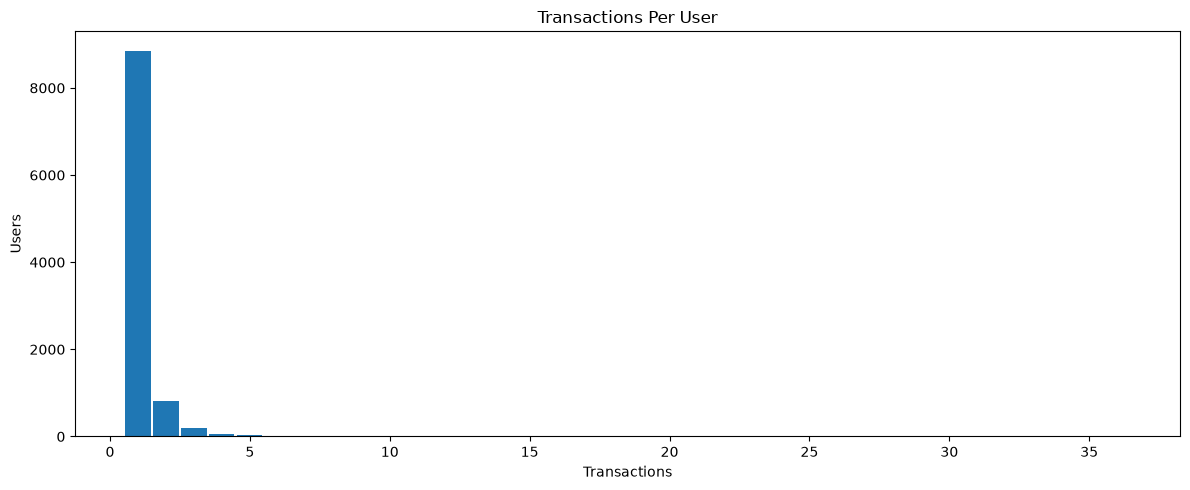

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(df_tran_per_user['total_transactions'], df_tran_per_user['users'], width=0.9, color='tab:blue')
ax.set_title('Transactions Per User')
ax.set_xlabel('Transactions')
ax.set_ylabel('Users')
plt.tight_layout()
plt.savefig('../images/transactions_per_user.png', dpi=150)
plt.show()

In [20]:
query_spend_per_order = """
SELECT
    FLOOR(totals.totalTransactionRevenue / 1000000 / 25) * 25 AS spend_bucket,
    COUNT(*) AS sessions
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE totals.totalTransactionRevenue IS NOT NULL
GROUP BY spend_bucket
ORDER BY spend_bucket
"""

df_spend_per_order = client.query(query_spend_per_order).to_dataframe()
df_spend_per_order = df_spend_per_order[df_spend_per_order['spend_bucket'] <= 1000]
df_spend_per_order['pct'] = (df_spend_per_order['sessions'] / df_spend_per_order['sessions'].sum() * 100).round(2)
df_spend_per_order.head(10)

,spend_bucket,sessions,pct
0,0.0,2148,19.01
1,25.0,3152,27.89
2,50.0,1756,15.54
3,75.0,1063,9.41
4,100.0,733,6.49
5,125.0,392,3.47
6,150.0,302,2.67
7,175.0,238,2.11
8,200.0,205,1.81
9,225.0,147,1.3


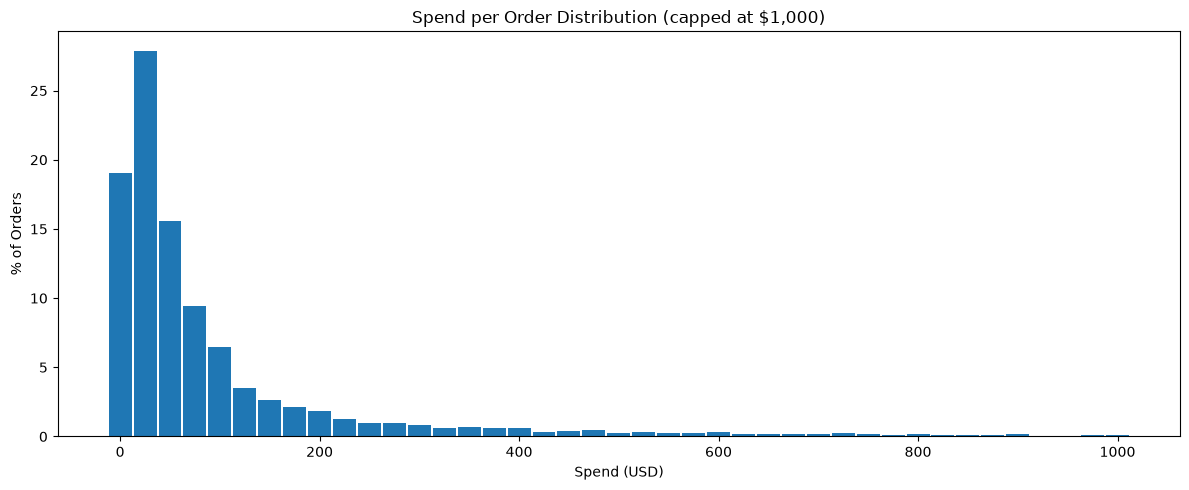

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(df_spend_per_order['spend_bucket'], df_spend_per_order['pct'], width=23, color='tab:blue')
ax.set_title('Spend per Order Distribution (capped at $1,000)')
ax.set_xlabel('Spend (USD)')
ax.set_ylabel('% of Orders')
plt.tight_layout()
plt.savefig('../images/spend_per_order_dist.png', dpi=150)
plt.show()

**Insights:**

Transactions per user:
1. 88% of buyers purchase only once - single-transaction users dominate completely, with a sharp drop to 8% buying twice and almost nothing beyond 3.
2. Repeat buyers are rare - only ~4% of buyers made 3 or more purchases.

Spend per order:
1. Most orders fall between &#36;25-&#36;75 - these two buckets alone account for ~43% of all purchasing sessions.
2. Median (&#36;56) vs avg (&#36;155) gap is large - a small number of high-spend orders (&#36;1,000+) inflate the average significantly.
3. Long tail could represent corporate or bulk buyers worth flagging.

#### High-Spend Sessions — Outlier Check
*The spend distribution above is capped at &#36;1,000. Check what's beyond that.*

In [22]:
query_high_spend = """
SELECT
    ROUND(totals.totalTransactionRevenue / 1000000, 2) AS revenue,
    totals.transactions AS transactions,
    trafficSource.source AS source,
    trafficSource.medium AS medium,
    channelGrouping,
    geoNetwork.country AS country,
    device.browser AS browser
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE totals.totalTransactionRevenue / 1000000 > 1000
ORDER BY revenue DESC
LIMIT 20
"""
df_high_spend = client.query(query_high_spend).to_dataframe()
print(f"Sessions spending >$1,000: {len(df_high_spend)}")
df_high_spend

Sessions spending >$1,000: 20


,revenue,transactions,source,medium,channelGrouping,country,browser
0,47082.06,2,dfa,cpm,Display,United States,Firefox
1,32153.82,3,dfa,cpm,Display,United States,Firefox
2,25249.26,2,(direct),(none),Direct,United States,Chrome
3,17859.50,1,(direct),(none),Direct,United States,Firefox
4,16032.75,1,(direct),(none),Direct,United States,Chrome
5,14060.31,2,(direct),(none),Direct,United States,Chrome
6,9227.74,6,google,organic,Organic Search,Venezuela,Chrome
7,8680.83,1,dfa,cpm,Display,United States,Firefox
8,8257.80,1,(direct),(none),Referral,United States,Chrome
9,7003.50,1,(direct),(none),Referral,United States,Chrome


**Insights:**
1. `dfa/cpm` (Display) owns the top 2 spots - &#36;47K and &#36;32K from just 2-3 transactions each. It appears 4 times in the top 20, confirming that a small number of extreme Display orders are responsible for the channel's inflated AOV seen in Section 7d.
2. Direct traffic is the backbone of legitimate high-spend orders - 12 of 20 sessions arrived directly (typed URL or bookmark), all US, Chrome or Firefox. These look like real corporate or high-intent buyers.
3. Venezuela appears twice (rows 6 and 13) with 6 transactions each via `google/organic` - unusual given Venezuela had near-zero presence in the country analysis. Likely bulk orders from a single buyer.
4. All 20 sessions are US or Venezuela - consistent with the geography finding that the US dominates transactions and very few markets generate real revenue.

## 7. Monthly Trends & Channel Performance
*How do traffic, spend, and channel mix change across the year?*

The daily sessions time series in `01_data_overview.ipynb` showed clear seasonality: traffic peaked at ~4,700 sessions/day in Nov-Dec 2016 then dropped sharply to ~1,500 in January. This section tracks monthly patterns across the full year - conversion rate, spend per order, channel mix, and channel quality - to understand what drives performance beyond just volume.

### 7a. Monthly Traffic & Conversion Trend
*Sessions and conversion rate by month, Nov–Dec highlighted*

In [23]:
query_monthly = """
SELECT
    SUBSTR(_TABLE_SUFFIX, 1, 6) AS month,
    COUNT(*) AS sessions,
    SUM(IFNULL(totals.transactions, 0)) AS transactions,
    ROUND(SUM(IFNULL(totals.transactions, 0)) / COUNT(*) * 100, 2) AS conversion_rate_pct,
    ROUND(SUM(IFNULL(totals.totalTransactionRevenue, 0)) / 1000000, 0) AS revenue,
    ROUND(SUM(totals.totalTransactionRevenue) / 1000000 / SUM(totals.transactions), 2) AS avg_order_value,
    ROUND(SUM(IFNULL(totals.totalTransactionRevenue, 0)) / 1000000 / COUNT(*), 2) AS avg_revenue_per_session
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
GROUP BY month
ORDER BY month
"""
df_monthly = client.query(query_monthly).to_dataframe()
df_monthly['month_label'] = pd.to_datetime(df_monthly['month'], format='%Y%m').dt.strftime('%b %Y')
df_monthly

,month,sessions,transactions,conversion_rate_pct,revenue,avg_order_value,avg_revenue_per_session,month_label
0,201608,74759,1241,1.66,189977.0,153.08,2.54,Aug 2016
1,201609,71032,904,1.27,136614.0,151.12,1.92,Sep 2016
2,201610,97506,919,0.94,124416.0,135.38,1.28,Oct 2016
3,201611,113972,955,0.84,132891.0,139.15,1.17,Nov 2016
4,201612,79124,1450,1.83,167324.0,115.40,2.11,Dec 2016
5,201701,64694,713,1.10,106248.0,149.02,1.64,Jan 2017
6,201702,62192,733,1.18,116112.0,158.41,1.87,Feb 2017
7,201703,69931,993,1.42,150225.0,151.28,2.15,Mar 2017
8,201704,67126,959,1.43,222768.0,232.29,3.32,Apr 2017
9,201705,65371,1160,1.77,135952.0,117.20,2.08,May 2017


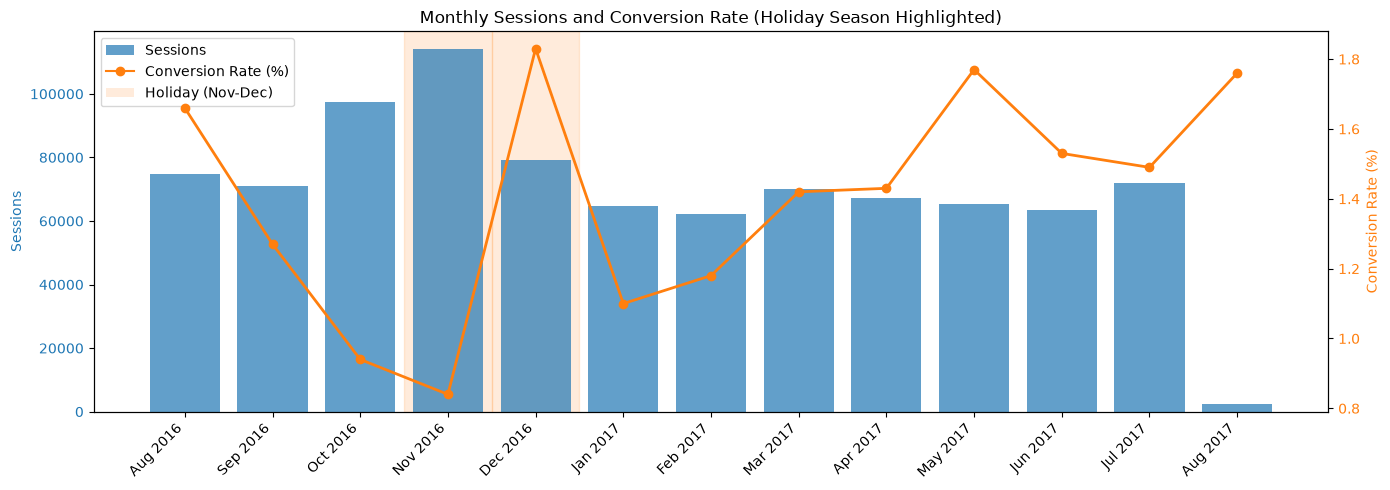

In [24]:
fig, ax1 = plt.subplots(figsize=(14, 5))

for i, row in df_monthly.iterrows():
    if row['month'] in ('201611', '201612'):
        ax1.axvspan(i - 0.5, i + 0.5, alpha=0.15, color='tab:orange')

ax1.bar(range(len(df_monthly)), df_monthly['sessions'], color='tab:blue', alpha=0.7)
ax1.set_ylabel('Sessions', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticks(range(len(df_monthly)))
ax1.set_xticklabels(df_monthly['month_label'], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(range(len(df_monthly)), df_monthly['conversion_rate_pct'], color='tab:orange', marker='o', linewidth=2)
ax2.set_ylabel('Conversion Rate (%)', color='tab:orange')   # label the right axis
ax2.tick_params(axis='y', labelcolor='tab:orange')          # color the right axis ticks orange

legend_elements = [
    Patch(facecolor='tab:blue', alpha=0.7, label='Sessions'),
    plt.Line2D([0], [0], color='tab:orange', marker='o', label='Conversion Rate (%)'),
    Patch(facecolor='tab:orange', alpha=0.15, label='Holiday (Nov-Dec)')
]
ax1.legend(handles=legend_elements, loc='upper left')
ax1.set_title('Monthly Sessions and Conversion Rate (Holiday Season Highlighted)')
plt.tight_layout()
plt.savefig('../images/monthly_trend.png', dpi=150)
plt.show()

**Insights:**
1. Nov 2016 had the most sessions (114K) but the lowest conversion rate (0.84%) - the traffic spike brought browsers, not buyers.
2. Dec 2016 flipped: fewer sessions (79K) but the highest conversion rate (1.83%) - last-minute buyers are decisive.
3. Oct 2016 shows the same pattern as Nov - high sessions (98K), low conversion (0.94%) - the pre-holiday ramp inflates volume without intent.
4. Post-holiday drop is sharp: Jan 2017 transactions nearly halved from Dec (713 vs 1,450) and conversion fell to 1.10%.

#### Data Completeness Check
*Aug 2017 appears in the chart but may be a partial month. Verify how many days of data exist per month.*

In [25]:
query_days_per_month = """
SELECT
    SUBSTR(_TABLE_SUFFIX, 1, 6) AS month,
    COUNT(DISTINCT _TABLE_SUFFIX) AS days_of_data
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
GROUP BY month
ORDER BY month
"""
df_days = client.query(query_days_per_month).to_dataframe()
df_days['month_label'] = pd.to_datetime(df_days['month'], format='%Y%m').dt.strftime('%b %Y')
df_days

,month,days_of_data,month_label
0,201608,31,Aug 2016
1,201609,30,Sep 2016
2,201610,31,Oct 2016
3,201611,30,Nov 2016
4,201612,31,Dec 2016
5,201701,31,Jan 2017
6,201702,28,Feb 2017
7,201703,31,Mar 2017
8,201704,30,Apr 2017
9,201705,31,May 2017


**Insights:**
1. All months have complete data (28-31 days) except Aug 2017, which has only 1 day.
2. Aug 2017 metrics should not be compared against other months - they represent a single day, not a full month.

### 7b. Spend by Month
*Avg order value and avg revenue per session by month

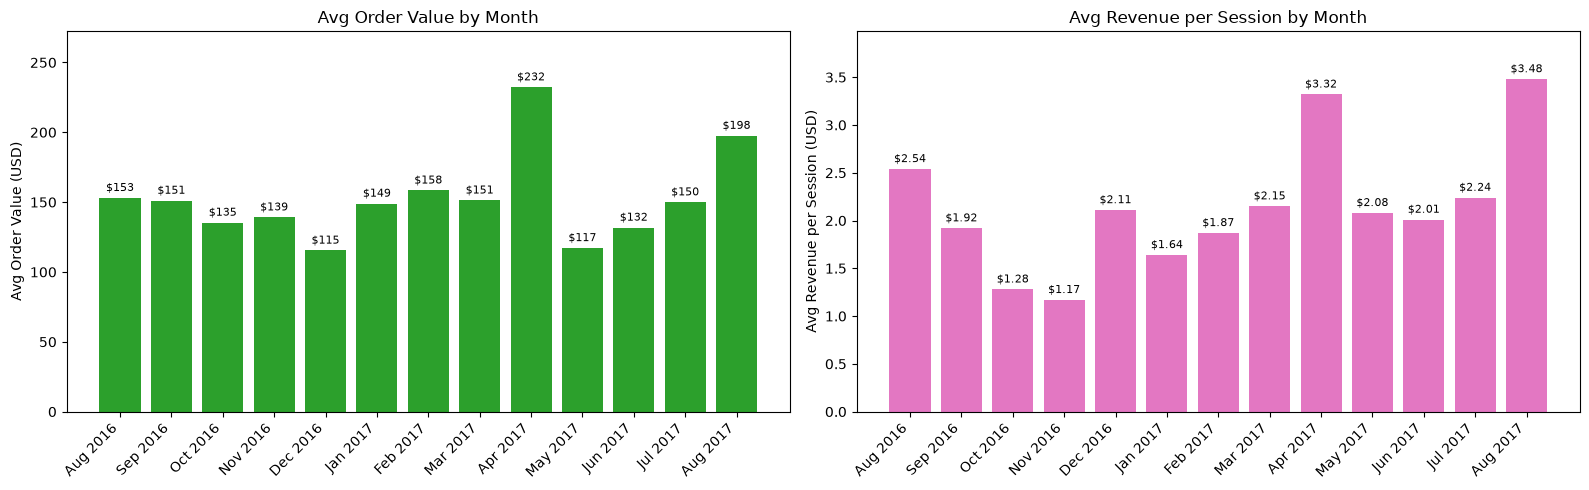

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# left: avg order value by month
bars1 = axes[0].bar(range(len(df_monthly)), df_monthly['avg_order_value'], color='tab:green')
axes[0].bar_label(bars1, fmt='$%.0f', padding=3, fontsize=8)
axes[0].set_title('Avg Order Value by Month')
axes[0].set_ylabel('Avg Order Value (USD)')
axes[0].set_xticks(range(len(df_monthly)))
axes[0].set_xticklabels(df_monthly['month_label'], rotation=45, ha='right')
axes[0].set_ylim(0, df_monthly['avg_order_value'].max() + 40)

# right: avg revenue per session by month
bars2 = axes[1].bar(range(len(df_monthly)), df_monthly['avg_revenue_per_session'], color='tab:pink')
axes[1].bar_label(bars2, fmt='$%.2f', padding=3, fontsize=8)
axes[1].set_title('Avg Revenue per Session by Month')
axes[1].set_ylabel('Avg Revenue per Session (USD)')
axes[1].set_xticks(range(len(df_monthly)))
axes[1].set_xticklabels(df_monthly['month_label'], rotation=45, ha='right')
axes[1].set_ylim(0, df_monthly['avg_revenue_per_session'].max() + 0.5)

plt.tight_layout()
plt.savefig('../images/spend_monthly.png', dpi=150)
plt.show()

**Insights:**
1. Dec 2016 has the highest conversion rate (1.83%) but one of the lowest AOVs (&#36;115) - holiday buyers are decisive but buy cheaper items, likely lower-price gifts rather than big-ticket purchases.
2. Nov 2016 is the worst revenue-efficiency month - most sessions of any month but the lowest avg revenue per session (&#36;1.17), combining low conversion with below-average AOV.
3. Holiday season does not mean higher spend per order - both Nov and Dec AOVs sit below the full-year average (~&#36;150).
4. Apr 2017 is the real standout - highest AOV (&#36;232) and highest avg revenue per session (&#36;3.32), neither a holiday nor a high-traffic month. Worth investigating in the campaign analysis section. Aug 2017 is the second highest AOV (&#36;198) but covers only 1 day of data, so it is not a meaningful comparison.

### 7c. Channel Mix by Month
*Does the share of each traffic channel shift month over month?*

In [27]:
query_channel_mix = """
SELECT
    SUBSTR(_TABLE_SUFFIX, 1, 6) AS month,
    channelGrouping,
    COUNT(*) AS sessions
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE trafficSource.source != 'analytics.google.com'
GROUP BY month, channelGrouping
ORDER BY month, sessions DESC
"""
df_channel_mix = client.query(query_channel_mix).to_dataframe()
df_channel_mix['month_label'] = pd.to_datetime(df_channel_mix['month'], format='%Y%m').dt.strftime('%b %Y')
df_channel_mix.head(15)

,month,channelGrouping,sessions,month_label
0,201608,Social,25372,Aug 2016
1,201608,Organic Search,24143,Aug 2016
2,201608,Direct,12163,Aug 2016
3,201608,Referral,8433,Aug 2016
4,201608,Affiliates,1909,Aug 2016
5,201608,Paid Search,1467,Aug 2016
6,201608,Display,449,Aug 2016
7,201608,(Other),2,Aug 2016
8,201609,Organic Search,25637,Sep 2016
9,201609,Social,24727,Sep 2016


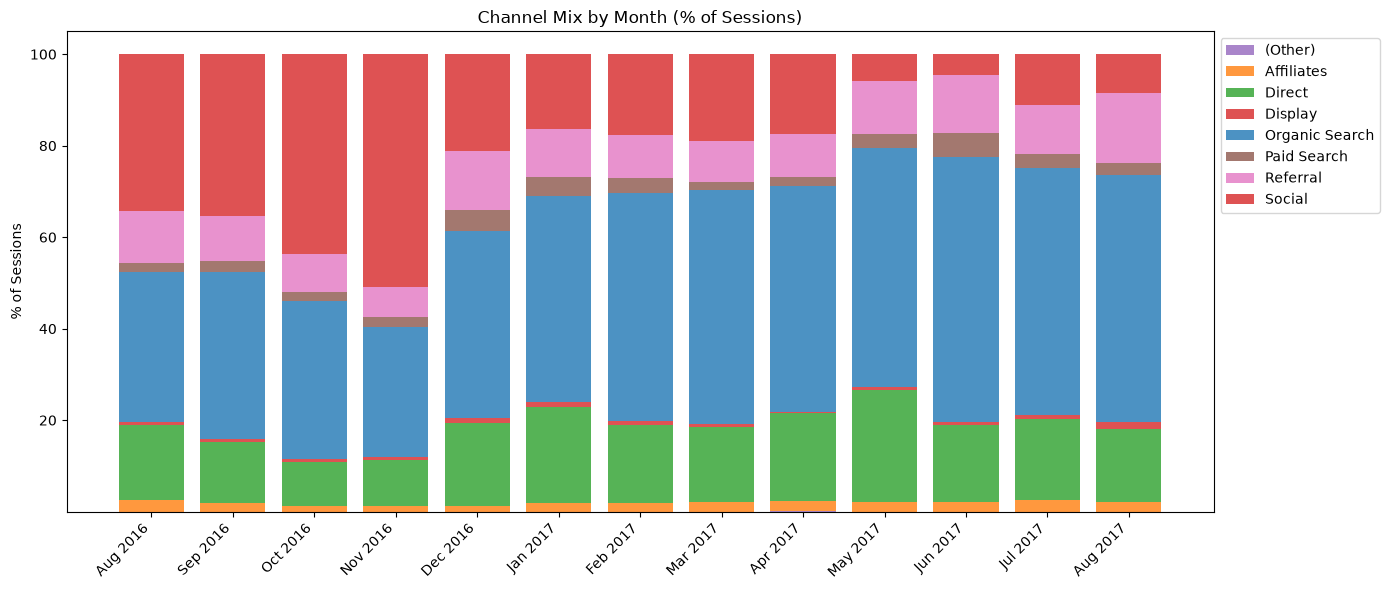

In [28]:
# pivot: months as rows, channels as columns
df_pivot = df_channel_mix.pivot_table(index='month', columns='channelGrouping', values='sessions', aggfunc='sum').fillna(0)
df_pivot_pct = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100
month_labels = pd.to_datetime(df_pivot_pct.index, format='%Y%m').strftime('%b %Y')

colors = ['tab:purple', 'tab:orange', 'tab:green', 'tab:red', 'tab:blue', 'tab:brown', 'tab:pink', 'tab:red']
fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(df_pivot_pct))

for i, channel in enumerate(df_pivot_pct.columns):
    ax.bar(range(len(df_pivot_pct)), df_pivot_pct[channel], bottom=bottom,
           label=channel, color=colors[i % len(colors)], alpha = 0.8)
    bottom += df_pivot_pct[channel].values

ax.set_title('Channel Mix by Month (% of Sessions)')
ax.set_ylabel('% of Sessions')
ax.set_xticks(range(len(df_pivot_pct)))
ax.set_xticklabels(month_labels, rotation=45, ha='right')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('../images/channel_mix_monthly.png', dpi=150)
plt.show()

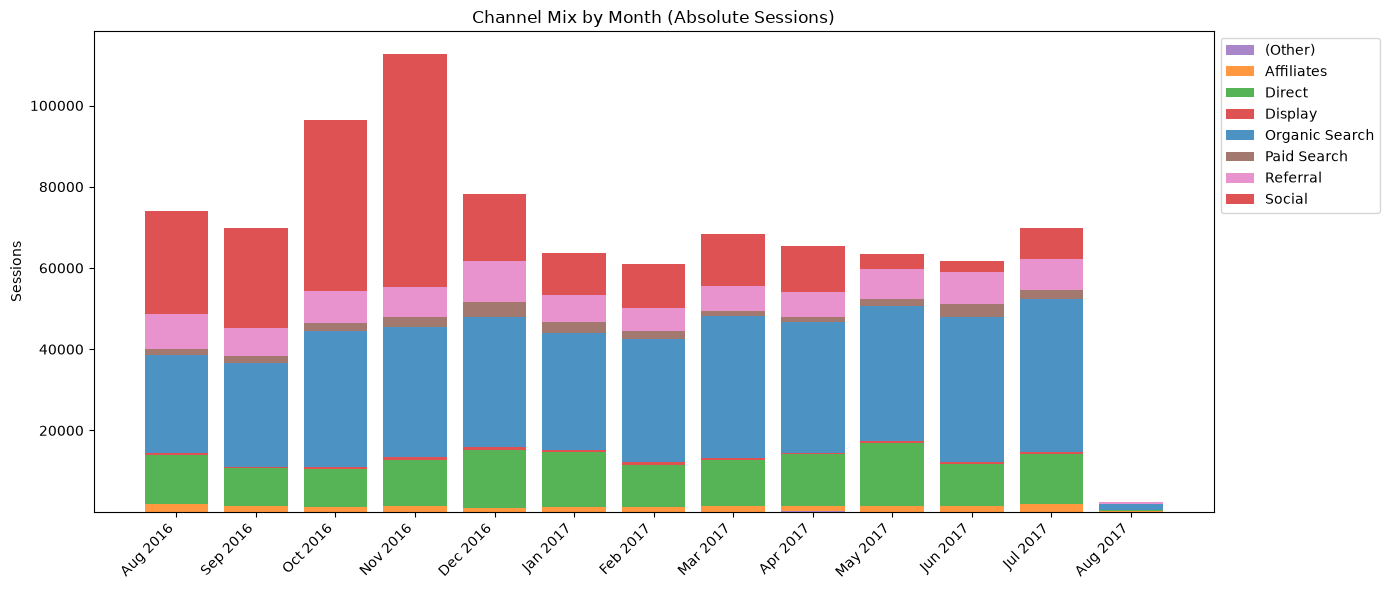

In [29]:
colors = ['tab:purple', 'tab:orange', 'tab:green', 'tab:red', 'tab:blue', 'tab:brown', 'tab:pink', 'tab:red']
fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(df_pivot))

for i, channel in enumerate(df_pivot.columns):
    ax.bar(range(len(df_pivot)), df_pivot[channel], bottom=bottom,
           label=channel, color=colors[i % len(colors)], alpha=0.8)
    bottom += df_pivot[channel].values

ax.set_title('Channel Mix by Month (Absolute Sessions)')
ax.set_ylabel('Sessions')
ax.set_xticks(range(len(df_pivot)))
ax.set_xticklabels(month_labels, rotation=45, ha='right')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('../images/channel_mix_monthly_abs.png', dpi=150)
plt.show()

**Insights:**
1. Social's Nov 2016 spike was real and massive in absolute terms - Social drove ~55-60K sessions in Oct-Nov 2016, nearly half the total. It collapsed drastically from Dec onwards.
2. Organic Search did NOT grow after Nov - it stayed flat at ~40-50K sessions throughout the year. Its rising % share in 2017 was entirely because Social vanished, not because organic improved.
3. The Nov to Dec session drop (114K to 79K) is almost fully explained by Social disappearing - all other channels stayed roughly stable in absolute terms.
4. Direct sessions grew modestly in 2017 - from ~12-15K in late 2016 to ~15-18K, the only channel that shows a genuine gradual upward trend.
5. Paid Search and Display are tiny in both absolute and relative terms throughout.

### 7d. Conversion Rate & AOV by Channel
*Full year | Which channels bring buyers and how much do they spend?*

In [30]:
query_channel_perf = """
SELECT
    channelGrouping,
    COUNT(*) AS sessions,
    SUM(IFNULL(totals.transactions, 0)) AS transactions,
    ROUND(SUM(IFNULL(totals.transactions, 0)) / COUNT(*) * 100, 2) AS conversion_rate_pct,
    ROUND(SUM(IFNULL(totals.totalTransactionRevenue, 0)) / 1000000, 0) AS revenue,
    ROUND(SUM(totals.totalTransactionRevenue) / 1000000 / SUM(totals.transactions), 2) AS avg_order_value
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE trafficSource.source != 'analytics.google.com'
GROUP BY channelGrouping
ORDER BY sessions DESC
"""
df_channel_perf = client.query(query_channel_perf).to_dataframe()
df_channel_perf['transactions'] = df_channel_perf['transactions'].fillna(0).astype(int)
df_channel_perf['conversion_rate_pct'] = df_channel_perf['conversion_rate_pct'].fillna(0)
df_channel_perf['avg_order_value'] = df_channel_perf['avg_order_value'].fillna(0)
df_channel_perf

,channelGrouping,sessions,transactions,conversion_rate_pct,revenue,avg_order_value
0,Organic Search,381561,3581,0.94,377076.0,105.30
1,Social,226117,131,0.06,8397.0,64.10
2,Direct,143026,2219,1.55,498530.0,224.66
3,Referral,88666,5543,6.25,717600.0,129.46
4,Paid Search,25326,479,1.89,47543.0,99.26
5,Affiliates,16403,9,0.05,654.0,72.71
6,Display,6262,152,2.43,130337.0,857.48
7,(Other),120,1,0.83,12.0,11.99


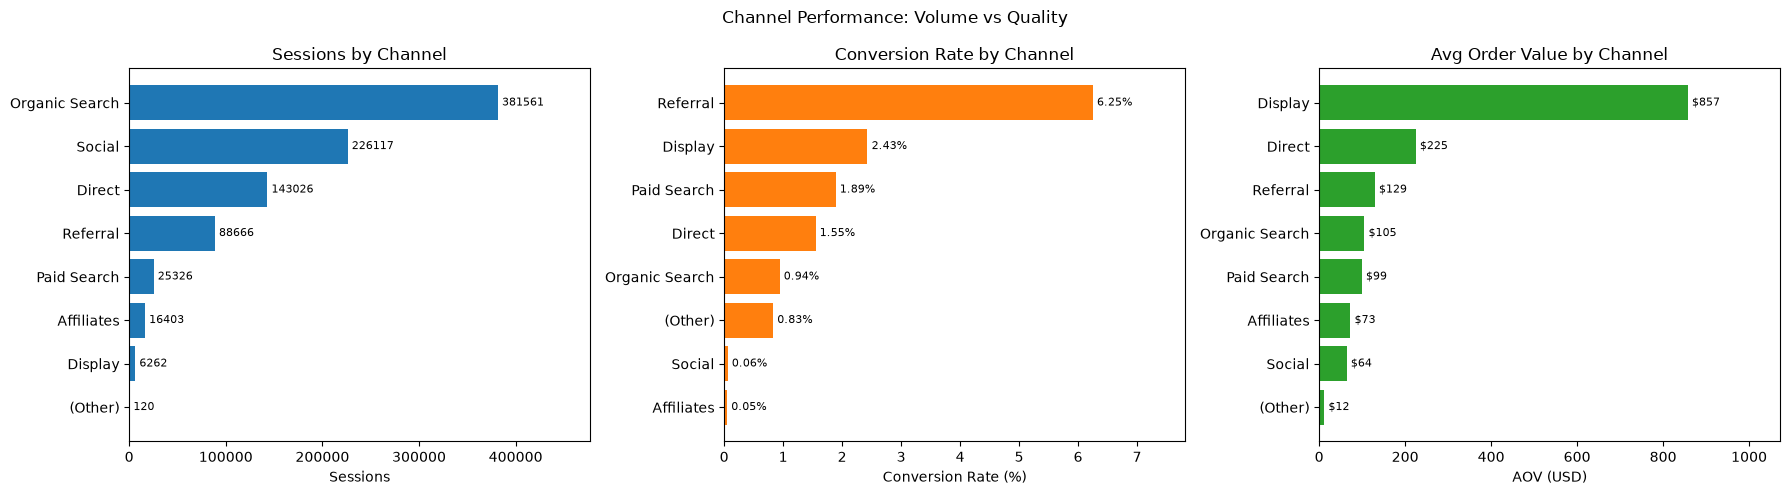

In [31]:
by_sessions = df_channel_perf.sort_values('sessions')
by_conv = df_channel_perf.sort_values('conversion_rate_pct')
by_aov = df_channel_perf[df_channel_perf['avg_order_value'] > 0].sort_values('avg_order_value')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# left: sessions by channel
bars1 = axes[0].barh(by_sessions['channelGrouping'], by_sessions['sessions'], color='tab:blue')
axes[0].bar_label(bars1, fmt='%.0f', padding=3, fontsize=8)
axes[0].set_title('Sessions by Channel')
axes[0].set_xlabel('Sessions')
axes[0].set_xlim(0, by_sessions['sessions'].max() * 1.25)

# middle: conversion rate by channel
bars2 = axes[1].barh(by_conv['channelGrouping'], by_conv['conversion_rate_pct'], color='tab:orange')
axes[1].bar_label(bars2, fmt='%.2f%%', padding=3, fontsize=8)
axes[1].set_title('Conversion Rate by Channel')
axes[1].set_xlabel('Conversion Rate (%)')
axes[1].set_xlim(0, by_conv['conversion_rate_pct'].max() * 1.25)

# right: AOV by channel
bars3 = axes[2].barh(by_aov['channelGrouping'], by_aov['avg_order_value'], color='tab:green')
axes[2].bar_label(bars3, fmt='$%.0f', padding=3, fontsize=8)
axes[2].set_title('Avg Order Value by Channel')
axes[2].set_xlabel('AOV (USD)')
axes[2].set_xlim(0, by_aov['avg_order_value'].max() * 1.25)

plt.suptitle('Channel Performance: Volume vs Quality', fontsize=12)
plt.tight_layout()
plt.savefig('../images/channel_performance.png', dpi=150)
plt.show()

**Insights:**
1. Referral is the highest-quality channel - ~6.25% conversion rate (after excluding `analytics.google.com`, which contributed 16K sessions and 0 transactions), nearly 4x higher than any other channel, and the top revenue generator (&#36;718K) despite ranking 4th in sessions. These are high-intent visitors arriving via curated links (e.g. `sites.google.com`, `siliconvalley.about.com`).
2. Social is the worst trade-off - 226K sessions (2nd most) but only 0.06% conversion and &#36;8K revenue. Referral has less than half the sessions but generates 85x more revenue. YouTube drives reach, not buyers.
3. Direct visitors spend the most per order (&#36;225 AOV) - those people already know what they want and commit to larger purchases.
4. Display AOV (&#36;857) needs scrutiny - only 152 transactions from 6K sessions. Like Japan's AOV, a few large orders could be inflating the mean. Worth verifying in campaign analysis.
5. Organic Search is the volume leader but underwhelming commercially - 381K sessions at only 0.94% conversion. Most visitors are browsing, not buying.
6. Affiliates are near-zero value - 16K sessions, 9 transactions (0.05%). The affiliate program is not working.
7. Paid Search converts at 1.89% - 2x Organic Search's rate (0.94%) - but AOV is lower (&#36;99 vs &#36;105). Strong conversion quality makes it under-invested relative to its session volume.

## 8. Campaign Analysis
*Full year | Top campaigns by traffic, conversion rate, and revenue*

In [32]:
query_campaign = """
SELECT
    trafficSource.campaign AS campaign,
    trafficSource.source AS source,
    trafficSource.medium AS medium,
    COUNT(*) AS sessions,
    SUM(IFNULL(totals.transactions, 0)) AS transactions,
    ROUND(SUM(IFNULL(totals.transactions, 0)) / COUNT(*) * 100, 2) AS conversion_rate_pct,
    ROUND(SUM(IFNULL(totals.totalTransactionRevenue, 0)) / 1000000, 0) AS revenue,
    ROUND(SUM(totals.totalTransactionRevenue) / 1000000 / SUM(totals.transactions), 2) AS avg_order_value
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE trafficSource.campaign NOT IN ('(not set)', '(organic)', '(none)')
GROUP BY campaign, source, medium
ORDER BY revenue DESC
"""
df_campaign = client.query(query_campaign).to_dataframe()
df_campaign['transactions'] = df_campaign['transactions'].fillna(0).astype(int)
df_campaign['conversion_rate_pct'] = df_campaign['conversion_rate_pct'].fillna(0)
df_campaign['avg_order_value'] = df_campaign['avg_order_value'].fillna(0)
df_campaign

,campaign,source,medium,sessions,transactions,conversion_rate_pct,revenue,avg_order_value
0,AW - Accessories,google,cpc,5327,100,1.88,15556.0,155.56
1,AW - Dynamic Search Ads Whole Site,google,cpc,6213,141,2.27,11882.0,84.27
2,Data Share Promo,Partners,affiliate,16402,9,0.05,654.0,72.71
3,AW - Apparel,google,cpc,32,0,0.00,0.0,0.00
4,All Products,google,cpc,4,0,0.00,0.0,0.00
5,Data Share,Partners,affiliate,1,0,0.00,0.0,0.00
6,Data Share Promo,Partners,(not set),1,0,0.00,0.0,0.00
7,AW - Electronics,google,cpc,74,0,0.00,0.0,0.00


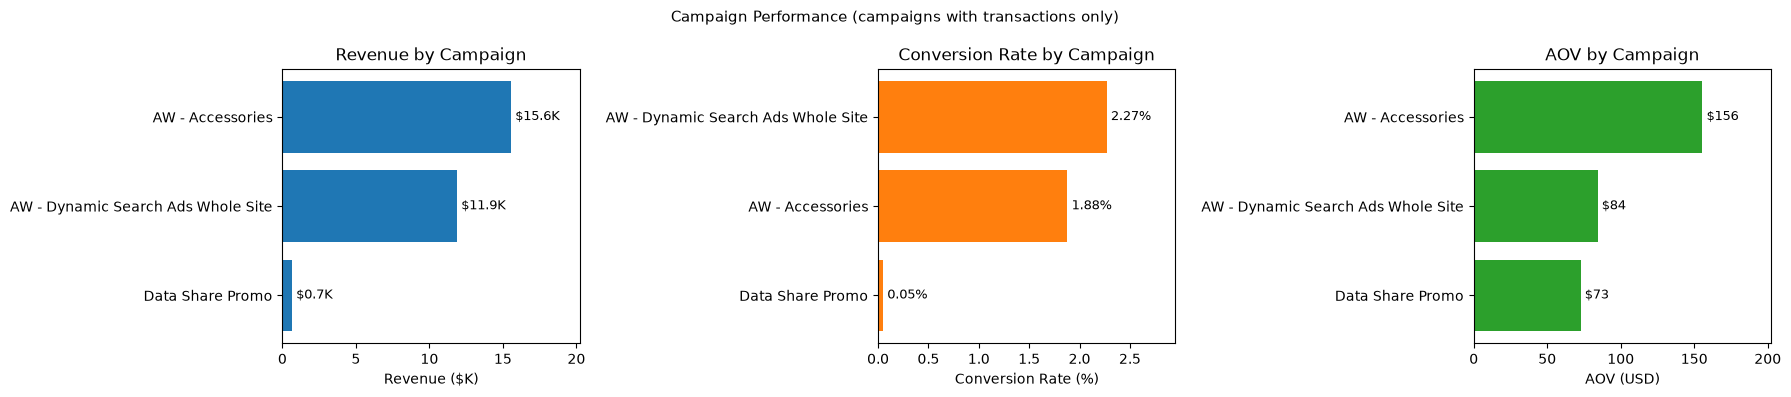

In [33]:
df_active = df_campaign[df_campaign['transactions'] > 0].copy()
by_rev = df_active.sort_values('revenue')
by_conv = df_active.sort_values('conversion_rate_pct')
by_aov = df_active.sort_values('avg_order_value')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

bars1 = axes[0].barh(by_rev['campaign'], by_rev['revenue'] / 1000, color='tab:blue')
axes[0].bar_label(bars1, fmt='$%.1fK', padding=3, fontsize=9)
axes[0].set_title('Revenue by Campaign')
axes[0].set_xlabel('Revenue ($K)')
axes[0].set_xlim(0, by_rev['revenue'].max() / 1000 * 1.3)

bars2 = axes[1].barh(by_conv['campaign'], by_conv['conversion_rate_pct'], color='tab:orange')
axes[1].bar_label(bars2, fmt='%.2f%%', padding=3, fontsize=9)
axes[1].set_title('Conversion Rate by Campaign')
axes[1].set_xlabel('Conversion Rate (%)')
axes[1].set_xlim(0, by_conv['conversion_rate_pct'].max() * 1.3)

bars3 = axes[2].barh(by_aov['campaign'], by_aov['avg_order_value'], color='tab:green')
axes[2].bar_label(bars3, fmt='$%.0f', padding=3, fontsize=9)
axes[2].set_title('AOV by Campaign')
axes[2].set_xlabel('AOV (USD)')
axes[2].set_xlim(0, by_aov['avg_order_value'].max() * 1.3)

plt.suptitle('Campaign Performance (campaigns with transactions only)', fontsize=11)
plt.tight_layout()
plt.savefig('../images/campaign_performance.png', dpi=150)
plt.show()

**Insights:**
1. Campaign tracking is very sparse - only 3 campaigns generated any transactions, totalling &#36;28K revenue out of &#36;1.78M total. The vast majority of sessions have no named campaign (`(not set)`, `(organic)`, `(none)` - see sidenotes for what these mean).
2. Both revenue-generating paid campaigns use google/cpc - "AW" stands for AdWords (Google's ad platform, now called Google Ads). `cpc` = cost per click, meaning the store pays Google each time someone clicks the ad.
3. `AW - Accessories` generates more revenue (&#36;15.6K) despite fewer sessions than `AW - Dynamic Search Ads Whole Site` (5.3K vs 6.2K). Its &#36;156 AOV is nearly double Dynamic Search's &#36;84, meaning accessory buyers spend more per order.
4. `AW - Dynamic Search Ads Whole Site` converts better (2.27% vs 1.88%) - Dynamic Search automatically matches a wide range of queries to the whole site, catching more varied buyer intent.
5. `Data Share Promo` drove 16K affiliate sessions but only 9 transactions (0.05% CR) - confirming the Affiliates channel failure seen in Section 7d. Traffic without buying intent.
6. `AW - Apparel` and `AW - Electronics` are effectively dormant - 106 combined sessions and zero transactions over the full year.

### 8b. April 2017 Deep Dive - What Drove the High AOV?
*Apr 2017 had the highest AOV (&#36;232) and avg revenue per session (&#36;3.32) of any month. What was different?*

In [34]:
query_april = """
SELECT
    trafficSource.source AS source,
    trafficSource.medium AS medium,
    trafficSource.campaign AS campaign,
    COUNT(*) AS sessions,
    SUM(IFNULL(totals.transactions, 0)) AS transactions,
    ROUND(SUM(IFNULL(totals.totalTransactionRevenue, 0)) / 1000000, 0) AS revenue,
    ROUND(SUM(totals.totalTransactionRevenue) / 1000000 / SUM(totals.transactions), 2) AS avg_order_value
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE SUBSTR(_TABLE_SUFFIX, 1, 6) = '201704'
AND totals.transactions > 0
GROUP BY source, medium, campaign
ORDER BY revenue DESC
"""
df_april = client.query(query_april).to_dataframe()
df_april['avg_order_value'] = df_april['avg_order_value'].fillna(0)
df_april

,source,medium,campaign,sessions,transactions,revenue,avg_order_value
0,(direct),(none),(not set),598,624,99197.0,158.97
1,dfa,cpm,(not set),8,11,93244.0,8476.70
2,google,organic,(not set),271,273,24227.0,88.74
3,google,cpc,AW - Accessories,19,19,4204.0,221.27
4,google,cpc,AW - Dynamic Search Ads Whole Site,6,6,507.0,84.42
5,yahoo,organic,(not set),4,4,283.0,70.82
6,mail.google.com,referral,(not set),3,3,213.0,71.06
7,siliconvalley.about.com,referral,(not set),2,2,201.0,100.41
8,l.facebook.com,referral,(not set),4,4,179.0,44.64
9,groups.google.com,referral,(not set),4,4,154.0,38.59


In [35]:
# confirm dfa belongs to the Display channelGrouping
query_dfa_channel = """
SELECT channelGrouping, COUNT(*) AS sessions
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE trafficSource.source = 'dfa'
GROUP BY channelGrouping
"""
print("channelGrouping for source = 'dfa':")
display(client.query(query_dfa_channel).to_dataframe())

channelGrouping for source = 'dfa':


,channelGrouping,sessions
0,Display,5686


In [36]:
# dfa/cpm row in April - the outlier driving April's inflated AOV
print("dfa/cpm row in April:")
display(df_april[df_april['source'] == 'dfa'][['source', 'medium', 'sessions', 'transactions', 'revenue', 'avg_order_value']])

dfa/cpm row in April:


,source,medium,sessions,transactions,revenue,avg_order_value
1,dfa,cpm,8,11,93244.0,8476.7


In [37]:
# April AOV: full vs. excluding dfa/cpm
total_rev = df_april['revenue'].sum()
total_txn = df_april['transactions'].sum()

dfa_rev = df_april[df_april['source'] == 'dfa']['revenue'].sum()
dfa_txn = df_april[df_april['source'] == 'dfa']['transactions'].sum()

adj_rev = total_rev - dfa_rev
adj_txn = total_txn - dfa_txn

print(f"April (all):               ${total_rev:>10,.0f} revenue  |  {int(total_txn):>4d} transactions  |  AOV = ${total_rev/total_txn:,.2f}")
print(f"dfa/cpm only:              ${dfa_rev:>10,.0f} revenue  |  {int(dfa_txn):>4d} transactions  |  AOV = ${dfa_rev/dfa_txn:,.2f}")
print(f"April (excluding dfa/cpm): ${adj_rev:>10,.0f} revenue  |  {int(adj_txn):>4d} transactions  |  AOV = ${adj_rev/adj_txn:,.2f}")

April (all):               $   222,767 revenue  |   959 transactions  |  AOV = $232.29
dfa/cpm only:              $    93,244 revenue  |    11 transactions  |  AOV = $8,476.73
April (excluding dfa/cpm): $   129,523 revenue  |   948 transactions  |  AOV = $136.63


In [38]:
# confirm whether Japan's high AOV is also driven by dfa/cpm (Display)
query_japan_sources = """
SELECT
    trafficSource.source AS source,
    trafficSource.medium AS medium,
    channelGrouping,
    ROUND(totals.totalTransactionRevenue / 1000000, 2) AS revenue
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE geoNetwork.country = 'Japan'
AND totals.totalTransactionRevenue IS NOT NULL
ORDER BY revenue DESC
"""
print("Japan transactions by source/medium:")
display(client.query(query_japan_sources).to_dataframe())

Japan transactions by source/medium:


,source,medium,channelGrouping,revenue
0,(direct),(none),Organic Search,3394.80
1,(direct),(none),Direct,2336.65
2,google,organic,Organic Search,1054.00
3,google,organic,Organic Search,180.97
4,(direct),(none),Referral,104.60
5,(direct),(none),Referral,102.95
6,google,organic,Organic Search,88.85
7,(direct),(none),Direct,56.97
8,(direct),(none),Organic Search,49.94
9,google,organic,Organic Search,42.98


**Insights:**
1. April's &#36;232 AOV is an outlier illusion - a single `dfa/cpm` cluster (8 sessions, 11 transactions) generated &#36;93,244 at &#36;8,477 AOV, accounting for 42% of April's total revenue. The calculation above confirms: excluding dfa/cpm, April AOV drops to ~&#36;137 - completely normal.
2. `dfa/cpm` belongs to the Display channelGrouping (confirmed by the query above) - the same channel flagged for suspicious &#36;857 AOV in Section 7d. April confirms it: a handful of very large Display-attributed orders inflate both the channel and monthly averages.
3. Direct traffic is the real driver of April's revenue - 598 sessions, &#36;99K at &#36;159 AOV. This is normal high-intent Direct behavior, not an anomaly.
4. Japan's outliers are a different story - the top 3 Japan orders (&#36;3,395 / &#36;2,337 / &#36;1,054) came from Direct and Organic Search, not dfa/cpm. Unlike Display, there is no single ad source to blame; Japan just happened to have 3 genuine large orders in a very small sample (17 total). The shared lesson across Japan (Section 4), Display (Section 7d), and April: when n is small, always check for outliers and compare mean vs median before trusting AOV.

## 9. Summary

### The Business in One Line
The Google Merchandise Store is almost entirely a US-based, Chrome-desktop, Direct/Referral business. Everything else is either negligible or not converting.

---

### Key Findings

**Geography & Market Concentration**
- The US generates 94% of transactions from 40% of sessions (3.14% conversion). Canada is the only other market with real traction (0.77%). Every other country - including India (51K sessions), Vietnam (24K sessions), and the UK (37K sessions) - converts below 0.16%.
- International traffic is largely wasted reach. If marketing budget is spent globally, the ROI outside the US and Canada is near zero.

**Channel Quality**
- Referral is the best channel by far: ~6.25% conversion rate (after excluding `analytics.google.com`), highest total revenue (&#36;718K), despite ranking 4th in sessions. High-intent visitors arriving via curated links outperform every other channel.
- Social is the worst trade-off: 226K sessions (2nd most) but only &#36;8K revenue and 0.06% conversion. YouTube drives reach, not buyers.
- Paid Search punches above its weight at 1.89% conversion (2x Organic), but with limited session volume it remains under-invested.
- Affiliates are effectively dead: 16K sessions, 9 transactions, &#36;654 revenue.

**Engagement Predicts Purchase**
- Purchasers view a median of 37 pages vs 2 for non-purchasers - a 19x gap. Below ~10 pageviews, almost no one buys. High page depth is the strongest leading indicator of purchase intent available in this dataset.

**Monthly Trends**
- November drove the most sessions ever (114K) but the lowest conversion rate (0.84%) - holiday traffic volume is mostly browse-and-leave behavior.
- December had the highest conversion (1.83%) but one of the lowest AOVs (&#36;115). Holiday buyers are decisive but buy cheaper gifts, not big-ticket items.
- The holiday traffic spike was almost entirely Social (YouTube) - which vanished by January. Organic, Direct, and Referral stayed flat throughout.

**Campaign Tracking is Broken**
- Only 3 of 8 named campaigns generated any transactions. Named campaigns account for just &#36;28K of &#36;1.78M total revenue (<2%). The vast majority of sessions have no campaign attribution (`(not set)`, `(organic)`, `(none)`).
- `AW - Accessories` (&#36;15.6K, &#36;156 AOV) and `AW - Dynamic Search Ads Whole Site` (&#36;11.9K, 2.27% CR) are the only two campaigns delivering measurable value.

**AOV is Frequently Misleading**
- Display (&#36;857), Japan (&#36;424), and April (&#36;232) all appeared to be premium segments - but each was driven by a tiny number of extreme orders. Excluding the `dfa/cpm` cluster from April drops AOV from &#36;232 to &#36;137. Japan's &#36;424 AOV rests on 3 orders out of 17.
- Rule: when n is small, always check for outliers and compare mean vs median before treating AOV as a meaningful signal.

**Device & Browser**
- Chrome drives 90%+ of revenue at 1.76% conversion. Safari converts at 0.43% despite being the 2nd largest browser. Mobile browsers (Safari in-app, Android Webview) convert below 0.2%. The store is a desktop-first experience with essentially no mobile purchase behavior.

---

### What to Investigate Next
- **Funnel drop-off**: where exactly do high-pageview users abandon before purchase? (Phase 4)
- **Campaign budget reallocation**: Affiliates and dormant AW campaigns are spending with near-zero return. (Phase 5)
- **Mobile experience**: low mobile conversion may reflect a UX problem, not just audience intent. (Phase 8 dashboard)